In [1]:
import cv2
import torch

# Load the base model (for general use)
from uniflowmatch.models.ufm import UniFlowMatchConfidence
model = UniFlowMatchConfidence.from_pretrained("infinity1096/UFM-Base")

# Or load the refinement model (for higher accuracy)
from uniflowmatch.models.ufm import UniFlowMatchClassificationRefinement
model = UniFlowMatchClassificationRefinement.from_pretrained("infinity1096/UFM-Refine")

# High resolution model can be loaded via "infinity1096/UFM-Base-980" and "infinity1096/UFM-Refine-980"

# Set the model to evaluation mode
model.eval()

img1_file = '/home/rwang/source/roma/assets/toronto_A.jpg'
img2_file = '/home/rwang/source/roma/assets/toronto_B.jpg'
# Load images using cv2 or PIL
source_image = cv2.imread(img1_file)
target_image = cv2.imread(img2_file)
source_rgb = cv2.cvtColor(source_image, cv2.COLOR_BGR2RGB)  # Convert to RGB
target_rgb = cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Convert to torch tensors (uint8 or float32)
# Forward call takes care of normalizing uint8 images appropriate to the UFM model
source_image = torch.from_numpy(source_rgb)  # Shape: (H, W, 3)
target_image = torch.from_numpy(target_rgb)  # Shape: (H, W, 3)

# Predict correspondences
with torch.no_grad():
    result = model.predict_correspondences_batched(
        source_image=source_image,
        target_image=target_image,
    )

    flow = result.flow.flow_output[0].cpu().numpy()
    covisibility = result.covisibility.mask[0].cpu().numpy()

/home/rwang/miniconda3/envs/ufm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading pretrained dinov2_vitl14 from torch hub


Using cache found in /home/rwang/.cache/torch/hub/facebookresearch_dinov2_main
/home/rwang/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/rwang/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/rwang/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading pretrained dinov2_vitl14 from torch hub


Using cache found in /home/rwang/.cache/torch/hub/facebookresearch_dinov2_main


In [2]:
flow.shape

(2, 1530, 2040)

In [4]:
covisibility.shape, source_image.shape, target_image.shape

((1530, 2040), torch.Size([1530, 2040, 3]), torch.Size([1530, 2040, 3]))

In [6]:
b, hs, ws = 1, 1530, 2040
device = 'cpu'
im_A_coords = torch.meshgrid(
        (
            torch.linspace(-1 + 1 / hs, 1 - 1 / hs, hs, device=device),
            torch.linspace(-1 + 1 / ws, 1 - 1 / ws, ws, device=device),
        ),
        indexing = 'ij'
    )
im_A_coords = torch.stack((im_A_coords[1], im_A_coords[0]))
im_A_coords = im_A_coords[None].expand(b, 2, hs, ws)
im_A_coords.shape

torch.Size([1, 2, 1530, 2040])

In [8]:
flow[None].shape

(1, 2, 1530, 2040)

In [7]:
covisibility.min(), covisibility.max()

(np.float32(1.6617214e-12), np.float32(0.9898949))

In [15]:
im_A_to_im_B = torch.from_numpy(flow[None])
b, hs, ws = 1, 1530, 2040
certainty = torch.from_numpy(covisibility[None][None])
im_A_to_im_B = im_A_to_im_B.permute(
                0, 2, 3, 1
                )
    # Create im_A meshgrid
im_A_coords = torch.meshgrid(
        (
            torch.linspace(-1 + 1 / hs, 1 - 1 / hs, hs, device=device),
            torch.linspace(-1 + 1 / ws, 1 - 1 / ws, ws, device=device),
        ),
        indexing = 'ij'
    )
im_A_coords = torch.stack((im_A_coords[1], im_A_coords[0]))
im_A_coords = im_A_coords[None].expand(b, 2, hs, ws)
# certainty = certainty.sigmoid()  # logits -> probs
im_A_coords = im_A_coords.permute(0, 2, 3, 1)
if (im_A_to_im_B.abs() > 1).any() and True:
                wrong = (im_A_to_im_B.abs() > 1).sum(dim=-1) > 0
                certainty[wrong[:,None]] = 0
im_A_to_im_B = torch.clamp(im_A_to_im_B, -1, 1)

In [16]:
warp = torch.cat((im_A_coords, im_A_to_im_B), dim=-1)

In [17]:
warp.shape

torch.Size([1, 1530, 2040, 4])

In [22]:
import torch


def kde(x, std = 0.1, half = True, down = None):
    # use a gaussian kernel to estimate density
    if half:
        x = x.half() # Do it in half precision TODO: remove hardcoding
    if down is not None:
        scores = (-torch.cdist(x,x[::down])**2/(2*std**2)).exp()
    else:
        scores = (-torch.cdist(x,x)**2/(2*std**2)).exp()
    density = scores.sum(dim=-1)
    return density

def sample(
        matches,
        certainty,
        num=200,
        # sample_mode="threshold_balanced",
        sample_mode="threshold",
        sample_thresh=0.05
    ):
        if "threshold" in sample_mode:
            upper_thresh = sample_thresh
            certainty = certainty.clone()
            certainty[certainty > upper_thresh] = 1
        matches, certainty = (
            matches.reshape(-1, 4),
            certainty.reshape(-1),
        )
        print(matches.shape, len(certainty))
        expansion_factor = 4 if "balanced" in sample_mode else 1
        good_samples = torch.multinomial(certainty, 
                          num_samples = min(expansion_factor*num, len(certainty)), 
                          replacement=False)
        good_matches, good_certainty = matches[good_samples], certainty[good_samples]
        if "balanced" not in sample_mode:
            return good_matches, good_certainty
        density = kde(good_matches, std=0.1)
        p = 1 / (density+1)
        p[density < 10] = 1e-7 # Basically should have at least 10 perfect neighbours, or around 100 ok ones
        balanced_samples = torch.multinomial(p, 
                          num_samples = min(num,len(good_certainty)), 
                          replacement=False)
        return good_matches[balanced_samples], good_certainty[balanced_samples]

In [24]:
certainty = certainty.sigmoid() 
matches,certainty = sample(warp, certainty)

torch.Size([3121200, 4]) 3121200


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm

def make_matching_figure(
        img0, img1, mkpts0, mkpts1, color,
        kpts0=None, kpts1=None, text=[], dpi=75, path=None):
    # draw image pair
    assert mkpts0.shape[0] == mkpts1.shape[0], f'mkpts0: {mkpts0.shape[0]} v.s. mkpts1: {mkpts1.shape[0]}'
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=dpi)
    axes[0].imshow(img0, cmap='gray')
    axes[1].imshow(img1, cmap='gray')
    for i in range(2):   # clear all frames
        axes[i].get_yaxis().set_ticks([])
        axes[i].get_xaxis().set_ticks([])
        for spine in axes[i].spines.values():
            spine.set_visible(False)
    plt.tight_layout(pad=1)
    
    if kpts0 is not None:
        assert kpts1 is not None
        axes[0].scatter(kpts0[:, 0], kpts0[:, 1], c='w', s=2)
        axes[1].scatter(kpts1[:, 0], kpts1[:, 1], c='w', s=2)

    # draw matches
    if mkpts0.shape[0] != 0 and mkpts1.shape[0] != 0:
        fig.canvas.draw()
        transFigure = fig.transFigure.inverted()
        fkpts0 = transFigure.transform(axes[0].transData.transform(mkpts0))
        fkpts1 = transFigure.transform(axes[1].transData.transform(mkpts1))
        fig.lines = [matplotlib.lines.Line2D((fkpts0[i, 0], fkpts1[i, 0]),
                                            (fkpts0[i, 1], fkpts1[i, 1]),
                                            transform=fig.transFigure, c=color[i], linewidth=1)
                                        for i in range(len(mkpts0))]
        
        axes[0].scatter(mkpts0[:, 0], mkpts0[:, 1], c=color, s=4)
        axes[1].scatter(mkpts1[:, 0], mkpts1[:, 1], c=color, s=4)

    # put txts
    txt_color = 'k' if img0[:100, :200].mean() > 200 else 'w'
    fig.text(
        0.01, 0.99, '\n'.join(text), transform=fig.axes[0].transAxes,
        fontsize=15, va='top', ha='left', color=txt_color)

    # save or return figure
    if path:
        plt.savefig(str(path), bbox_inches='tight', pad_inches=0)
        plt.close()
    
    return fig

certainty (200,) 1.0 1.0
Matches 200 confidence 1.0 1.0


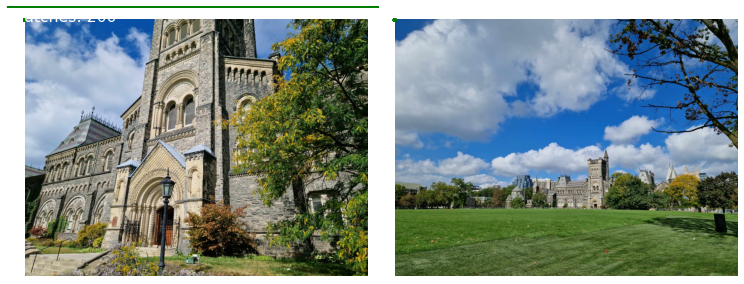

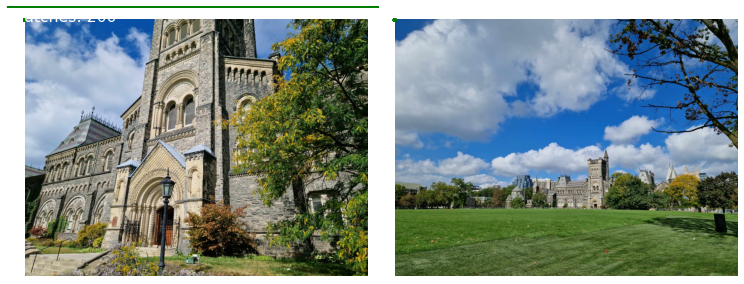

In [29]:


im1, im2 = source_rgb, target_rgb


# cv2.imwrite("/home/rwang/sample01.jpg", img0)
# cv2.imwrite("/home/rwang/sample02.jpg", img1)

kpts1, kpts2 = matches[:,:2], matches[:,2:]

mconf = certainty.cpu().numpy()
print('certainty', mconf.shape, mconf.min(), mconf.max())
mkpts0, mkpts1 = kpts1.cpu().numpy(), kpts2.cpu().numpy()
threshold = 0.2

valid_mask = mconf>threshold
mconf = mconf[valid_mask]
mkpts0 = mkpts0[valid_mask]
mkpts1 = mkpts1[valid_mask] 

print('Matches', len(mconf), 'confidence', mconf.min(), mconf.max())

# color = cm.jet(mconf)
color = ['g']*len(mconf)
text = [
    # 'Ours',
    'Matches: {}'.format(len(mkpts0)),
]

make_matching_figure(im1, im2, mkpts0, mkpts1, color, text=text)


In [32]:
mkpts0[0],mkpts1[0]
mkpts0[1],mkpts1[1]

(array([-0.1436274, -0.3379085], dtype=float32),
 array([1., 1.], dtype=float32))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm

def make_matching_figure(
        img0, img1, mkpts0, mkpts1, color,
        kpts0=None, kpts1=None, text=[], dpi=75, path=None):
    # draw image pair
    assert mkpts0.shape[0] == mkpts1.shape[0], f'mkpts0: {mkpts0.shape[0]} v.s. mkpts1: {mkpts1.shape[0]}'
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=dpi)
    axes[0].imshow(img0, cmap='gray')
    axes[1].imshow(img1, cmap='gray')
    for i in range(2):   # clear all frames
        axes[i].get_yaxis().set_ticks([])
        axes[i].get_xaxis().set_ticks([])
        for spine in axes[i].spines.values():
            spine.set_visible(False)
    plt.tight_layout(pad=1)
    
    if kpts0 is not None:
        assert kpts1 is not None
        axes[0].scatter(kpts0[:, 0], kpts0[:, 1], c='w', s=2)
        axes[1].scatter(kpts1[:, 0], kpts1[:, 1], c='w', s=2)

    # draw matches
    if mkpts0.shape[0] != 0 and mkpts1.shape[0] != 0:
        fig.canvas.draw()
        transFigure = fig.transFigure.inverted()
        fkpts0 = transFigure.transform(axes[0].transData.transform(mkpts0))
        fkpts1 = transFigure.transform(axes[1].transData.transform(mkpts1))
        fig.lines = [matplotlib.lines.Line2D((fkpts0[i, 0], fkpts1[i, 0]),
                                            (fkpts0[i, 1], fkpts1[i, 1]),
                                            transform=fig.transFigure, c=color[i], linewidth=1)
                                        for i in range(len(mkpts0))]
        
        axes[0].scatter(mkpts0[:, 0], mkpts0[:, 1], c=color, s=4)
        axes[1].scatter(mkpts1[:, 0], mkpts1[:, 1], c=color, s=4)

    # put txts
    txt_color = 'k' if img0[:100, :200].mean() > 200 else 'w'
    fig.text(
        0.01, 0.99, '\n'.join(text), transform=fig.axes[0].transAxes,
        fontsize=15, va='top', ha='left', color=txt_color)

    # save or return figure
    if path:
        plt.savefig(str(path), bbox_inches='tight', pad_inches=0)
        plt.close()
    
    return fig